# UMNQ test notebook

**Use this notebook to verify your gnssrefl installation and demonstrate the
big_wave pipeline on one day of data.**

If anything below fails, you have an installation problem before you can
start running `main.py`. Cells are deliberately self-contained — they do
not import `config`, `snr`, `estimate`, or other project modules — so a
failure here is unambiguously a gnssrefl/environment problem, not a
project-code problem.

Sections:
1. **gnssrefl environment** — check that the package imports and exe is present
2. **RINEX → SNR** — convert one day from RINEX to gnssrefl's snr66 format
3. **Quick visual** — `quicklook` plot to confirm the SNR file is usable
4. **Station coordinates** — pull lat/lon/height from the RINEX header
5. **Web planning tools** — embedded geoid lookup + reflection zone visualizer
6. **Windowed + binned demo** — a one-day demonstration of the pipeline's
   sliding-window Lomb-Scargle + multi-sat consensus binning, all in
   ~30 lines of inline code (no project imports)


## 1. gnssrefl environment

`gnssrefl` reads `$REFL_CODE`, `$ORBITS`, `$EXE` from environment vars at
import time. Set them to point at the project's `data/refl_code/`.


In [40]:
import os
from pathlib import Path
from gnssrefl.utils import check_environment, set_environment, get_sys

# Point gnssrefl at the project's data/refl_code/ tree
project_dir  = Path.cwd().parents[0]
refl_code    = project_dir / 'data' / 'refl_code'

if not check_environment():
    set_environment(refl_code=str(refl_code),
                    orbits=str(refl_code / 'orbits'),
                    exe=str(refl_code / 'exe'))

print('REFL_CODE :', os.environ['REFL_CODE'])
print('ORBITS    :', os.environ['ORBITS'])
print('EXE       :', os.environ['EXE'])


REFL_CODE : /Users/brmills/Documents/SSiSLS/big_wave/data/refl_code
ORBITS    : /Users/brmills/Documents/SSiSLS/big_wave/data/refl_code/orbits
EXE       : /Users/brmills/Documents/SSiSLS/big_wave/data/refl_code/exe


## Install CRX2RNX (one-time)

`gnssrefl` ships a per-OS Hatanaka decompressor `CRX2RNX` (and optionally
`gfzrnx` for RINEX 3). If `exe/` is empty or missing the binary, run this:


In [41]:
from gnssrefl.installexe_cl import installexe

try:
    files = os.listdir(os.environ['EXE'])
    print('files in exe folder:', files)
    if not any(f.lower().startswith('crx2rnx') for f in files):
        installexe(get_sys())
except FileNotFoundError:
    installexe(get_sys())


files in exe folder: ['CRX2RNX', '.gitkeep', 'gfzrnx']


## 2. RINEX → SNR

Convert one Hatanaka-compressed RINEX file to gnssrefl's `snr66` format
using multi-GNSS SP3 orbits (`orb='gnss3'`). `nolook=True` tells gnssrefl
not to try downloading the RINEX from a remote archive — we already have
it locally.


In [42]:
import shutil
from gnssrefl.rinex2snr_cl import rinex2snr

station = 'umnq'
year    = 2026
doy     = 1

# Copy the local RINEX into the notebook's CWD where gnssrefl will find it
rinex_dir = project_dir / 'data' / 'rinex' / 'umnq-2025085-2026145'
src       = rinex_dir / f'{station}{doy:03d}0.{str(year)[-2:]}d.Z'
shutil.copy(src, os.getcwd())

rinex2snr(station=station, year=year, doy=doy,
          nolook=True, orb='gnss3', overwrite=True)


No json file found - but you have requested the code not exit
Using snr value of  66
Using command line orbit selection of  gnss3
Using archive value of  all
Station  umnq  has four characters, assume RINEX 2.11 format
Debug mode or only analyzing one day of data. 
SNR file exists/you requested overwriting, existing file will be deleted
umnq 2026 1
General log:  /Users/brmills/Documents/SSiSLS/big_wave/data/refl_code/logs/umnq/2026/001_translation.txt.gen
Will first assume station  umnq  year: 2026  doy: 1 is located here : /Users/brmills/Documents/SSiSLS/big_wave/notebooks
Looked for  /Users/brmills/Documents/SSiSLS/big_wave/notebooks/umnq0010.26o
Failed, will search other names/directories
Looking for file:  /Users/brmills/Documents/SSiSLS/big_wave/notebooks/umnq0010.26o.gz
Looking for file:  /Users/brmills/Documents/SSiSLS/big_wave/notebooks/umnq0010.26o.Z
Looking for file:  /Users/brmills/Documents/SSiSLS/big_wave/notebooks/umnq0010.26d
found  /Users/brmills/Documents/SSiSLS/big_wa

## 3. Quick visual sanity check

`quicklook` runs gnssrefl's built-in Lomb-Scargle on every arc and produces
a periodogram plot — handy to confirm the SNR file is well-formed and the
station has reflections in the expected RH range.


Did not find station coordinates : umnq
Although no station coordinates were found, this is ok for quickLook.
minimum elevation angle (degrees) for this dataset:  0.0002
Plot saved to  /Users/brmills/Documents/SSiSLS/big_wave/data/refl_code/Files/umnq/quickLook_lsp.png
Plot saved to  /Users/brmills/Documents/SSiSLS/big_wave/data/refl_code/Files/umnq/quickLook_summary.png


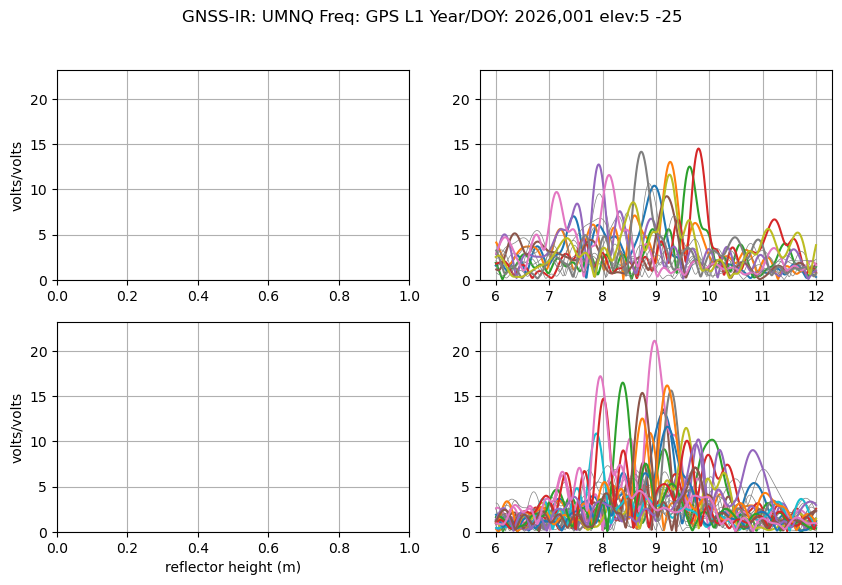

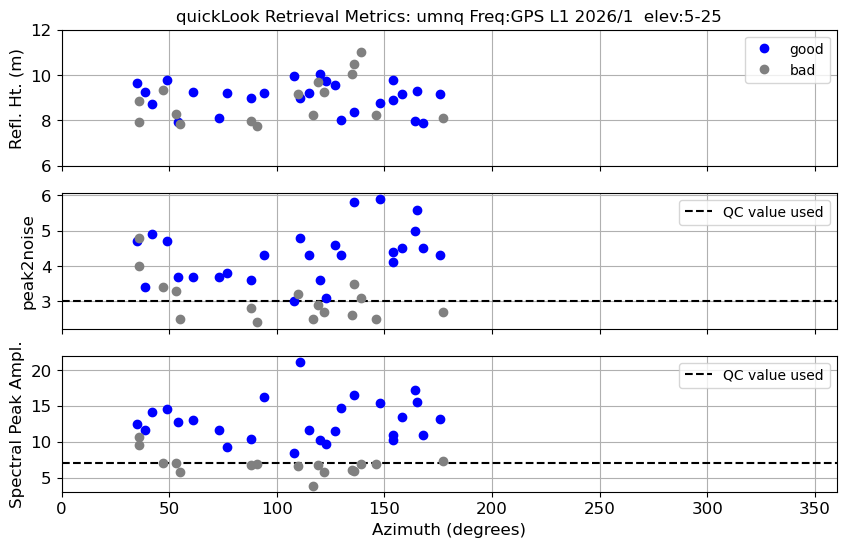

In [43]:
from gnssrefl.quickLook_cl import quicklook

values, metrics = quicklook(
    station, year, doy=doy,
    fr=1,            # 1=L1, 2=L2, 5=L5, 20=L2C, 101/102=Glonass L1/L2
    azim1=30,
    azim2=180,
    h1=6,            # RH search lower bound (m)
    h2=12,           # upper bound (m)
    plt=True,
)


## 4. Station coordinates

Pull lat/lon/ellipsoidal height directly from the RINEX header (the
`APPROX POSITION XYZ` record). Needed for the web planning tools below.


In [44]:
import math, subprocess, tempfile

def coords_from_rinex(rinex_path):
    """Extract lat/lon/height (WGS-84) from a RINEX 2 obs header.
    Handles .d.Z / .d.gz / .d via CRX2RNX in $EXE."""
    src = Path(rinex_path)
    crx2rnx = Path(os.environ['EXE']) / 'CRX2RNX'

    with tempfile.TemporaryDirectory() as tmp:
        tmp = Path(tmp); local = tmp / src.name
        shutil.copy(src, local)

        if local.suffix == '.Z':
            subprocess.run(['uncompress', '-f', str(local)], check=True)
            local = local.with_suffix('')
        elif local.suffix == '.gz':
            subprocess.run(['gunzip', '-f', str(local)], check=True)
            local = local.with_suffix('')
        if local.suffix.endswith('d'):
            subprocess.run([str(crx2rnx), str(local)], check=True)
            local = local.with_suffix(local.suffix[:-1] + 'o')

        with open(local) as f:
            for line in f:
                if 'APPROX POSITION XYZ' in line:
                    X, Y, Z = (float(v) for v in line.split()[:3])
                    break
                if 'END OF HEADER' in line:
                    raise ValueError('APPROX POSITION XYZ missing')

    # WGS-84 ECEF -> geodetic (Bowring's method)
    a, fl = 6378137.0, 1/298.257223563
    e2 = fl*(2-fl); b = a*(1-fl); ep2 = (a*a - b*b)/(b*b)
    p = math.hypot(X, Y); th = math.atan2(Z*a, p*b)
    lon = math.atan2(Y, X)
    lat = math.atan2(Z + ep2*b*math.sin(th)**3, p - e2*a*math.cos(th)**3)
    N = a / math.sqrt(1 - e2*math.sin(lat)**2)
    h = p/math.cos(lat) - N
    return math.degrees(lat), math.degrees(lon), h

lat, lon, height = coords_from_rinex(src)
print(f'Station {station.upper()}: lat={lat:.6f}, lon={lon:.6f}, h={height:.2f} m (ellipsoidal)')


Station UMNQ: lat=70.677526, lon=-52.115415, h=38.00 m (ellipsoidal)


## 5. Web planning tools

Two embedded tools from `gnss-reflections.org` use the coordinates we
just extracted: one looks up the geoid undulation (to convert ellipsoidal
↔ MSL heights), the other simulates reflection-zone Fresnel ellipses for
the configured elevation mask and azimuth range.

### Geoid lookup


In [45]:
from IPython.display import IFrame
from urllib.parse import urlencode

params = {
    'station': '',                  # must be present (even empty) or the server errors
    'lat':    f'{lat:.6f}',
    'lon':    f'{lon:.6f}',
    'height': f'{height:.2f}',
}
url = f'https://gnss-reflections.org/geoid?{urlencode(params)}'
print(url)
IFrame(url, width=1000, height=600)


https://gnss-reflections.org/geoid?station=&lat=70.677526&lon=-52.115415&height=38.00


### Reflection zones

The page below visualizes the Fresnel reflection footprints for given
elevation angles and azimuth sweep. Set `RH` to your nominal antenna-to-
water distance (≈10.88 m at UMNQ when first surveyed; the current
project-tuned value is 8.88 m).


In [46]:
params = {
    'station': station,
    'lat':    f'{lat:.6f}',
    'lon':    f'{lon:.6f}',
    'height': f'{height:.2f}',
    'msl':    'msl',          # subtract geoid -> RH measured from MSL
    'RH':     '10.88',         # nominal reflector height (m)
    'freq':   '1',             # L1
    'nyquist':'0',
    'srate':  '15',            # matches RINEX INTERVAL
    'eang':   '1',             # 5,10,15 deg preset
    'azim1':  '30',
    'azim2':  '180',
    'system': 'gps',
}
url = f'https://gnss-reflections.org/rzones?{urlencode(params)}'
print(url)
IFrame(url, width=900, height=600)


https://gnss-reflections.org/rzones?station=umnq&lat=70.677526&lon=-52.115415&height=38.00&msl=msl&RH=10.88&freq=1&nyquist=0&srate=15&eang=1&azim1=30&azim2=180&system=gps


## 6. Windowed + binned demonstration

Below is a from-scratch implementation of the project's core analysis
(everything is inlined — no `import config`, `import snr`, etc.) so this
notebook stands alone. The full project versions in `snr.py` and
`estimate.py` add caching, more constellations, edge-hit gates, parabolic
peak refinement, and so on, but the algorithm is exactly this:

1. **Load the SNR file** gnssrefl just produced
2. **Filter to the analysis window** (azimuth, elevation, RH range)
3. **Slide a 3-minute window** through each satellite arc, running
   Lomb-Scargle on every enabled signal per window
4. **Bin by time** across all satellites and signals using an
   inverse-variance weighted mean (multi-sat consensus)
5. **Plot** raw windowed obs underneath, binned obs on top


In [47]:
import numpy as np
import pandas as pd
import gzip
from dataclasses import dataclass
from scipy.signal import lombscargle

C_LIGHT = 299_792_458.0

@dataclass(frozen=True)
class Signal:
    name: str
    snr_col: str
    freq_hz: float
    prn_lo: int
    prn_hi: int

    @property
    def wavelength_m(self): return C_LIGHT / self.freq_hz

# GPS L1/L2/L5, Galileo E1/E5a/E5b, GLONASS G1/G2 (nominal channel-0 freqs)
SIGNALS = (
    Signal('GPS_L1',  'S1', 1575.42e6,   1,  32),
    Signal('GPS_L2',  'S2', 1227.60e6,   1,  32),
    Signal('GPS_L5',  'S5', 1176.45e6,   1,  32),
    Signal('GAL_E1',  'S1', 1575.42e6, 201, 299),
    Signal('GAL_E5a', 'S5', 1176.45e6, 201, 299),
    Signal('GAL_E5b', 'S7', 1207.14e6, 201, 299),
    Signal('GLO_G1',  'S1', 1602.0e6,  101, 199),
    Signal('GLO_G2',  'S2', 1246.0e6,  101, 199),
)
print(f'{len(SIGNALS)} signals enabled, λ from '
      f'{min(s.wavelength_m for s in SIGNALS)*100:.1f} cm '
      f'to {max(s.wavelength_m for s in SIGNALS)*100:.1f} cm')


8 signals enabled, λ from 18.7 cm to 25.5 cm


In [48]:
# Locate the snr66 file we made above
yy = str(year)[-2:]
snr_path = Path(os.environ['REFL_CODE']) / f'{year}' / 'snr' / station / f'{station}{doy:03d}0.{yy}.snr66.gz'
if not snr_path.exists():
    snr_path = snr_path.with_suffix('')  # uncompressed fallback

# snr66 columns (gnssrefl convention — note S6 before S1)
cols = ['sat','elev','azim','sec','edot','S6','S1','S2','S5','S7','S8']
opener = gzip.open if snr_path.suffix == '.gz' else open
with opener(snr_path, 'rt') as f:
    snr = pd.read_csv(f, sep=r'\s+', header=None, names=cols, usecols=range(11))
snr['sat'] = snr['sat'].astype(int)
# Absolute UTC time per row (sec is seconds-of-day)
epoch = pd.Timestamp(f'{year}-01-01', tz='UTC') + pd.Timedelta(days=doy-1)
snr['time_utc'] = epoch + pd.to_timedelta(snr['sec'], unit='s')

print(f'Loaded {len(snr):,} SNR rows from {snr_path.name}')
print(f'Constellations present:')
for lo, hi, name in [(1,99,'GPS'), (101,199,'GLONASS'), (201,299,'Galileo')]:
    n = snr.sat.between(lo, hi).sum()
    if n:
        nsats = snr.loc[snr.sat.between(lo,hi), 'sat'].nunique()
        print(f'  {name:8s}: {n:>6d} rows / {nsats} sats')


Loaded 72,465 SNR rows from umnq0010.26.snr66.gz
Constellations present:
  GPS     :  33994 rows / 32 sats
  GLONASS :  16203 rows / 19 sats
  Galileo :  22268 rows / 22 sats


In [58]:
# Analysis windows (hardcoded for this demo — matches project defaults)
AZ_MIN, AZ_MAX = 30.0, 180.0     # fjord-facing azimuth wedge
EL_MIN, EL_MAX = 5.0, 25.0       # elevation mask for Lomb-Scargle
RH_MIN, RH_MAX = 4.0, 16.0       # RH search range (m)
WINDOW_SEC = 300                  # sliding-window length (s)
STRIDE_SEC = 30                   # window stride (s)
MIN_WIN_PTS = 10                  # min valid samples per window

# Filter SNR to enabled-signal sats inside the az/el window, mark rise/set
enabled_prns = {p for s in SIGNALS for p in range(s.prn_lo, s.prn_hi+1)}
sub = snr[snr.sat.isin(enabled_prns)
        & snr.azim.between(AZ_MIN, AZ_MAX)
        & snr.elev.between(EL_MIN, EL_MAX)].copy()
sub['dir'] = np.where(sub.edot > 0, 'rise', 'set')
sub['arc_id'] = sub.groupby(['sat','dir']).ngroup()
print(f'Arcs to analyze: {sub.arc_id.nunique()} '
      f'(from {sub.sat.nunique()} sats; {len(sub):,} SNR rows after filtering)')

def estimate_rh(elev_deg, snr_db, wavelength):
    """Lomb-Scargle peak -> RH. Returns (rh, sigma_estimate, p2n)."""
    mask = snr_db > 0
    if mask.sum() < MIN_WIN_PTS:
        return np.nan, np.nan, np.nan
    e = elev_deg[mask]; snr_lin = 10 ** (snr_db[mask] / 20.0)
    se = np.sin(np.radians(e))
    # detrend with quadratic in sin(elev) to remove direct signal
    dsnr = snr_lin - np.polyval(np.polyfit(se, snr_lin, 2), se)
    heights = np.linspace(RH_MIN, RH_MAX, 1000)
    omegas = 4 * np.pi * heights / wavelength
    pg = lombscargle(se, dsnr, omegas, normalize=True)
    i = int(np.argmax(pg))
    p2n = float(pg[i] / np.median(pg))
    # Rough sigma: peak FWHM scaled by 1/sqrt(p2n)
    dh = float(heights[1] - heights[0])
    if 0 < i < len(pg) - 1:
        d2 = pg[i-1] + pg[i+1] - 2*pg[i]
        sigma = float(dh * np.sqrt(-pg[i] / d2) / np.sqrt(p2n)) if d2 < 0 else 0.5
    else:
        sigma = 0.5
    return float(heights[i]), sigma, p2n

# Sliding window per arc, all applicable signals per sat
half = pd.Timedelta(seconds=WINDOW_SEC/2)
stride = pd.Timedelta(seconds=STRIDE_SEC)
rows = []
for arc_id, arc in sub.groupby('arc_id'):
    sat = int(arc.sat.iloc[0])
    sigs = [s for s in SIGNALS if s.prn_lo <= sat <= s.prn_hi]
    t_min, t_max = arc.time_utc.min(), arc.time_utc.max()
    if t_max - t_min < pd.Timedelta(seconds=WINDOW_SEC):
        continue
    for t_c in pd.date_range(t_min + half, t_max - half, freq=stride):
        win = arc[arc.time_utc.between(t_c - half, t_c + half)]
        if len(win) < MIN_WIN_PTS: continue
        for sig in sigs:
            rh, sigma, p2n = estimate_rh(win.elev.values, win[sig.snr_col].values, sig.wavelength_m)
            if not np.isfinite(rh) or p2n < 2.5:
                continue
            rows.append({'t': t_c, 'sat': sat, 'signal': sig.name,
                         'rh': rh, 'sigma': sigma, 'p2n': p2n})

obs = pd.DataFrame(rows)
print(f'\nWindowed obs: {len(obs):,}  (across {obs.signal.nunique()} signals, {obs.sat.nunique()} sats)')
print(obs.groupby('signal').size().to_string())


Arcs to analyze: 114 (from 70 sats; 22,068 SNR rows after filtering)

Windowed obs: 20,343  (across 8 signals, 70 sats)
signal
GAL_E1     2422
GAL_E5a    2083
GAL_E5b    2079
GLO_G1     2177
GLO_G2     2062
GPS_L1     3869
GPS_L2     3471
GPS_L5     2180


In [59]:
# Multi-sat consensus binning: drop within-bin outliers, then
# inverse-variance weighted mean of survivors.
BIN_SEC = 120.0
MAX_SPREAD_M = 0.5

obs_b = obs.copy()
obs_b['_bin'] = obs_b['t'].dt.floor(f'{int(BIN_SEC)}s')
bin_td = pd.Timedelta(seconds=BIN_SEC)

binned_rows = []
for bin_start, g in obs_b.groupby('_bin'):
    rh_all = g['rh'].to_numpy()
    sigma_all = g['sigma'].to_numpy()
    med = float(np.median(rh_all))
    keep = np.abs(rh_all - med) <= MAX_SPREAD_M / 2.0
    if keep.sum() < 1:
        continue
    rh_k = rh_all[keep]; sig_k = sigma_all[keep]
    w = 1.0 / sig_k**2
    rh_mean = float((rh_k * w).sum() / w.sum())
    sigma_mean = float(1.0 / np.sqrt(w.sum()))
    binned_rows.append({
        't':       bin_start + bin_td / 2,
        'rh':      rh_mean,
        'sigma':   sigma_mean,
        'n_obs':   int(keep.sum()),
        'n_sats':  int(g.loc[keep, 'sat'].nunique()),
    })
binned = pd.DataFrame(binned_rows)
print(f'Binned: {len(obs):,} windowed obs -> {len(binned):,} bins')
print(f'Median σ: per-obs {obs.sigma.median()*100:.0f} cm '
      f'-> per-bin {binned.sigma.median()*100:.0f} cm '
      f'(median obs/bin = {binned.n_obs.median():.0f})')


Binned: 20,343 windowed obs -> 683 bins
Median σ: per-obs 59 cm -> per-bin 18 cm (median obs/bin = 7)


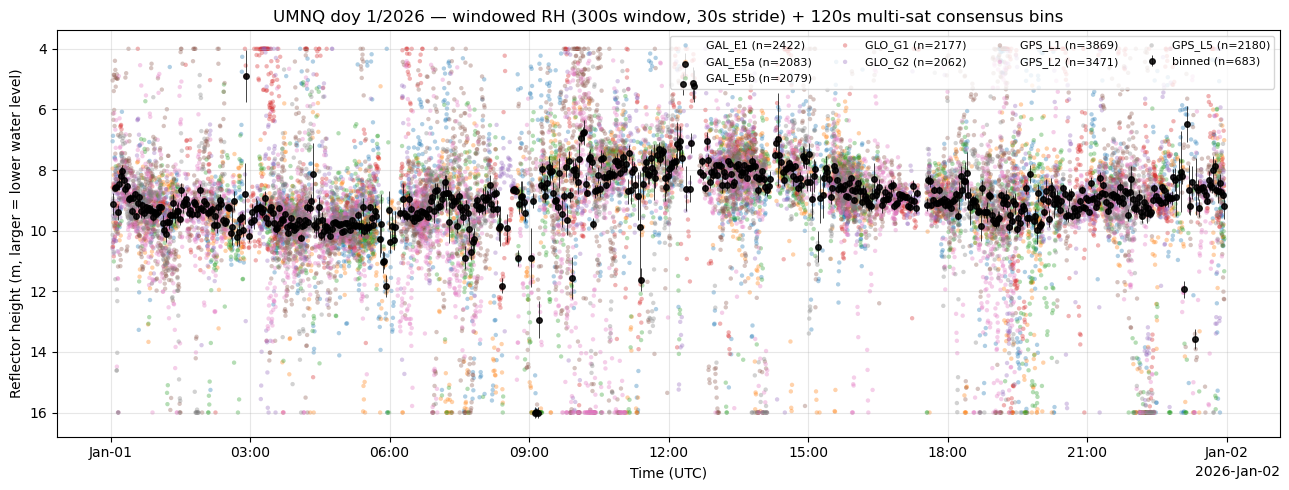

In [60]:
import matplotlib.pyplot as plt
from matplotlib.dates import AutoDateLocator, ConciseDateFormatter

fig, ax = plt.subplots(figsize=(13, 5))

# Raw windowed obs, colored by signal (faded)
for sig_name, group in obs.groupby('signal'):
    ax.scatter(group.t, group.rh, s=10, alpha=0.35,
               label=f'{sig_name} (n={len(group)})', edgecolors='none')

# Binned obs on top with σ error bars
ax.errorbar(binned.t, binned.rh, yerr=binned.sigma,
            fmt='o', ms=4, color='black', alpha=0.85,
            ecolor='black', elinewidth=0.6,
            label=f'binned (n={len(binned)})', zorder=5)

# Cosmetics
loc = AutoDateLocator()
ax.xaxis.set_major_locator(loc)
ax.xaxis.set_major_formatter(ConciseDateFormatter(loc))
ax.invert_yaxis()  # so rising water level (smaller RH) goes UP on the plot
ax.set_xlabel('Time (UTC)')
ax.set_ylabel('Reflector height (m, larger = lower water level)')
ax.set_title(f'{station.upper()} doy {doy}/{year} — windowed RH '
             f'({WINDOW_SEC}s window, {STRIDE_SEC}s stride) + '
             f'{int(BIN_SEC)}s multi-sat consensus bins')
ax.grid(alpha=0.3)
ax.legend(loc='best', fontsize=8, ncol=4)
plt.tight_layout()
